# 서울시 부동산 실거래가 예측 및 분석 프로젝트

이 노트북은 서울시 부동산 실거래가 데이터를 로드하고, 탐색적 데이터 분석(EDA)을 수행하며, 선형 회귀와 XGBoost 모델을 사용하여 가격을 예측하는 과정을 담고 있습니다.

In [9]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import joblib

# 한글 폰트 설정 (Mac 환경 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드
`datasets` 폴더 내의 CSV 파일들을 통합하여 로드합니다.

In [10]:
def load_data(data_path):
    """
    datasets 폴더 내의 서울시 부동산 실거래가 CSV 파일들을 로드하고 통합합니다.
    """
    csv_files = glob.glob(os.path.join(data_path, "*.csv"))
    
    # 컬럼 정의 (서울시 공공데이터 기준)
    columns = [
        '접수연도', '자치구코드', '자치구명', '법정동코드', '법정동명', 
        '지번구분', '지번구분명', '본번', '부번', '건물명', 
        '계약일', '물건금액(만원)', '건물면적(㎡)', '토지면적(㎡)', '층', 
        '권리구분', '취득유형', '건축년도', '건물용도', '신고구분', '신고기관'
    ]
    
    df_list = []
    for file in csv_files:
        print(f"Loading: {os.path.basename(file)}")
        try:
            temp_df = pd.read_csv(file, encoding='cp949', names=columns, header=None)
            df_list.append(temp_df)
        except Exception as e:
            print(f"Error loading {file}: {e}")
            
    if not df_list:
        return pd.DataFrame()
        
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # 데이터 전처리
    combined_df['계약일'] = pd.to_datetime(combined_df['계약일'], format='%Y%m%d', errors='coerce')
    
    numeric_cols = ['물건금액(만원)', '건물면적(㎡)', '토지면적(㎡)', '층', '건축년도']
    for col in numeric_cols:
        combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    return combined_df

## 2. 탐색적 데이터 분석 (EDA)
데이터의 통계 정보와 시각화 자료를 생성합니다.

In [11]:
def perform_eda(df):
    """
    기초 탐색적 데이터 분석(EDA)을 수행합니다.
    """
    if df.empty:
        print("데이터가 비어있습니다.")
        return
        
    # 상관관계 히트맵
    plt.figure(figsize=(10, 8))
    numeric_df = df[['물건금액(만원)', '건물면적(㎡)', '층', '건축년도']]
    corr_matrix = numeric_df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('수치형 변수 간 상관관계 히트맵')
    plt.tight_layout()
    plt.show()
    
    print("\n--- [데이터 요약 정보] ---")
    print(df.info())
    
    print("\n--- [자치구별 거래 건수 Top 10] ---")
    dist_counts = df['자치구명'].value_counts().head(10)
    print(dist_counts)
    
    print("\n--- [수치형 데이터 기초 통계] ---")
    numeric_cols = ['물건금액(만원)', '건물면적(㎡)', '층', '건축년도']
    print(df[numeric_cols].describe())
    
    # 자치구별 거래 건수 시각화
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x='자치구명', order=df['자치구명'].value_counts().index)
    plt.xticks(rotation=45)
    plt.title('서울시 자치구별 부동산 거래 현황')
    plt.tight_layout()
    plt.show()

## 3. 데이터 전처리
학습에 필요한 특성을 선택하고 결측치를 처리합니다.

In [12]:
def preprocess_data(df):
    """
    모델 학습에 적합하도록 데이터를 정제합니다. 
    """
    features = ['자치구명', '건물면적(㎡)', '층', '건축년도', '건물용도']
    target = '물건금액(만원)'
    all_needed_cols = features + [target]
    
    df = df.dropna(subset=all_needed_cols)
    df = df[(df['건축년도'] > 0) & (df['물건금액(만원)'] > 0) & (df['건물면적(㎡)'] > 0)]
    
    return df[all_needed_cols]

## 4. 모델 학습 - Linear Regression
기본적인 선형 회귀 모델을 구축하고 평가합니다.

In [1]:
def train_linear_regression(df):
    X = df[['자치구명', '건물면적(㎡)', '층', '건축년도', '건물용도']]
    y = df['물건금액(만원)']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    categorical_features = ['자치구명', '건물용도']
    numeric_features = ['건물면적(㎡)', '층', '건축년도']
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])
    
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    
    print("Linear Regression 모델 학습 중...")
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n--- [모델 평가 결과] ---")
    print(f"평균 절대 오차 (MAE): {mae:,.2f} 만원")
    print(f"결정계수 (R² Score): {r2:.4f}")
    
    plt.figure(figsize=(8, 8))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Price (만원)')
    plt.ylabel('Predicted Price (만원)')
    plt.title('Linear Regression: Actual vs Predicted')
    plt.show()
    
    return model

## 5. 모델 학습 - XGBoost
트리 기반의 강력한 앙상블 모델인 XGBoost를 사용하여 성능을 높입니다.

In [ ]:
def train_xgboost(df):
    X = df[['자치구명', '건물면적(㎡)', '층', '건축년도', '건물용도']]
    y = df['물건금액(만원)']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    categorical_features = ['자치구명', '건물용도']
    numeric_features = ['건물면적(㎡)', '층', '건축년도']
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
        ])
    
    # 모델 파이프라인 구성
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(random_state=42))
    ])
    
    # [하이퍼파라미터 튜닝 로직]
    param_grid = {
        'regressor__n_estimators': [100, 300, 500],
        'regressor__max_depth': [3, 5, 7],
        'regressor__learning_rate': [0.01, 0.05, 0.1]
    }
    
    print("최적의 하이퍼파라미터를 찾는 중입니다 (GridSearchCV)...")
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    # 최적의 모델 선택
    model = grid_search.best_estimator_
    print(f"찾아낸 최적 파라미터: {grid_search.best_params_}")
    
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n--- [XGBoost 모델 정밀 분석 결과] ---")
    print(f"평균 절대 오차 (MAE): {mae:,.2f} 만원")
    print(f"결정계수 (R² Score): {r2:.4f}")
    
    return model


## 6. 심층 데이터 분석: 상관관계 및 중요도 파악 (Report)

이 섹션에서는 각 변수가 부동산 가격(물건금액)에 어떤 영향을 미치는지 시각화합니다.

- **상관관계 히트맵**: 변수 간의 선형적 인과관계 파악
- **XGBoost Feature Importance**: 모델이 학습 시 주목한 변수
- **Permutation Importance**: 실제 예측 결과에 미치는 독립적 영향력 파악

In [15]:
def perform_detailed_analysis(model, df):
    X = df[['자치구명', '건물면적(㎡)', '층', '건축년도', '건물용도']]
    y = df['물건금액(만원)']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 1. 상관관계 히트맵 (색상 가독성 개선)
    plt.figure(figsize=(10, 8))
    numeric_cols = ['물건금액(만원)', '건물면적(㎡)', '층', '건축년도']
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdYlBu_r', fmt=".2f")
    plt.title('수치형 변수 간 상관관계 (Heatmap)', fontsize=15)
    plt.show()
    
    # 2. XGBoost Feature Importance
    xgb_model = model.named_steps['regressor']
    preprocessor = model.named_steps['preprocessor']
    
    cat_features = ['자치구명', '건물용도']
    num_features = ['건물면적(㎡)', '층', '건축년도']
    ohe_feature_names = list(preprocessor.transformers_[1][1].get_feature_names_out(cat_features))
    all_feature_names = num_features + ohe_feature_names
    
    importances = xgb_model.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    
    plt.figure(figsize=(10, 8))
    plt.title('XGBoost 모델이 학습 시 주목한 주요 변수 (Top 15)', fontsize=15)
    sns.barplot(x=importances[indices], y=[all_feature_names[i] for i in indices], palette="rocket")
    plt.show()
    
    # 3. Permutation Importance (가독성 대폭 개선 버전)
    print("\nPermutation Importance 계산 중... (데이터 양에 따라 시간이 소요될 수 있습니다)")
    result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
    
    # 평균 중요도를 기준으로 정렬
    sorted_idx = result.importances_mean.argsort()
    
    plt.figure(figsize=(10, 8))
    # 박스플롯 대신 직관적인 막대 그래프(Bar Chart) 사용
    sns.barplot(
        x=result.importances_mean[sorted_idx], 
        y=X.columns[sorted_idx], 
        palette="viridis"
    )
    
    plt.title("부동산 특징별 실질적 가격 영향력 (Permutation Importance)", fontsize=15, pad=20)
    plt.xlabel("상대적 중요도 (값이 클수록 예측에 결정적)", fontsize=12)
    plt.ylabel("부동산 특징 항목", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return result


## 7. 전체 실행 파이프라인
모든 과정을 순차적으로 실행하여 최종 리포트를 생성합니다.

Loading: 서울시 부동산 실거래가 정보 2026.csv
Loading: 서울시 부동산 실거래가 정보 2024.csv


/var/folders/6c/4yg7f8pn51z3n_xr3pxygkt40000gn/T/ipykernel_23454/3571870325.py:19: DtypeWarning: Columns (0,1,3,5,7,8,10,11,12,13,14,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file, encoding='cp949', names=columns, header=None)


Loading: 서울시 부동산 실거래가 정보 2025.csv


/var/folders/6c/4yg7f8pn51z3n_xr3pxygkt40000gn/T/ipykernel_23454/3571870325.py:19: DtypeWarning: Columns (0,1,3,5,7,8,10,11,12,13,14,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file, encoding='cp949', names=columns, header=None)


정제 후 데이터 수: 248014


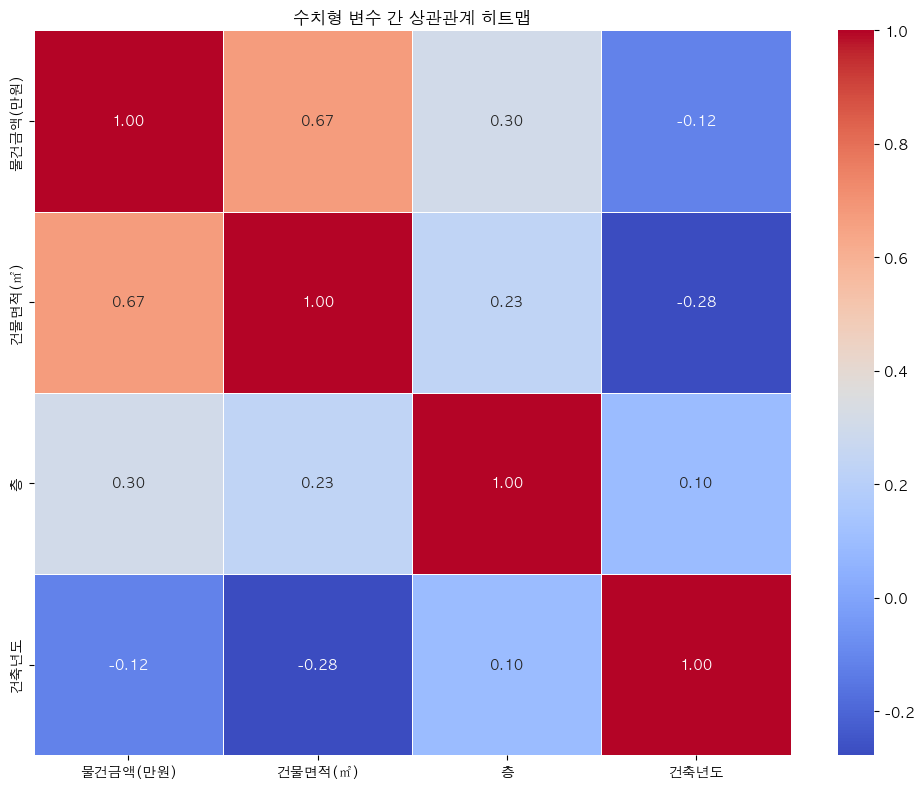


--- [데이터 요약 정보] ---
<class 'pandas.core.frame.DataFrame'>
Index: 248014 entries, 1 to 260106
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   자치구명      248014 non-null  object 
 1   건물면적(㎡)   248014 non-null  float64
 2   층         248014 non-null  float64
 3   건축년도      248014 non-null  float64
 4   건물용도      248014 non-null  object 
 5   물건금액(만원)  248014 non-null  float64
dtypes: float64(4), object(2)
memory usage: 13.2+ MB
None

--- [자치구별 거래 건수 Top 10] ---
자치구명
송파구     16644
강서구     16079
강동구     14029
노원구     12998
마포구     12470
은평구     12418
강남구     12067
양천구     11918
영등포구    11871
성북구     11310
Name: count, dtype: int64

--- [수치형 데이터 기초 통계] ---
           물건금액(만원)        건물면적(㎡)              층           건축년도
count  2.480140e+05  248014.000000  248014.000000  248014.000000
mean   8.936618e+04      62.749262       7.740946    2005.474651
std    8.476367e+04      29.939186       6.201767      11.681780
min    2.00

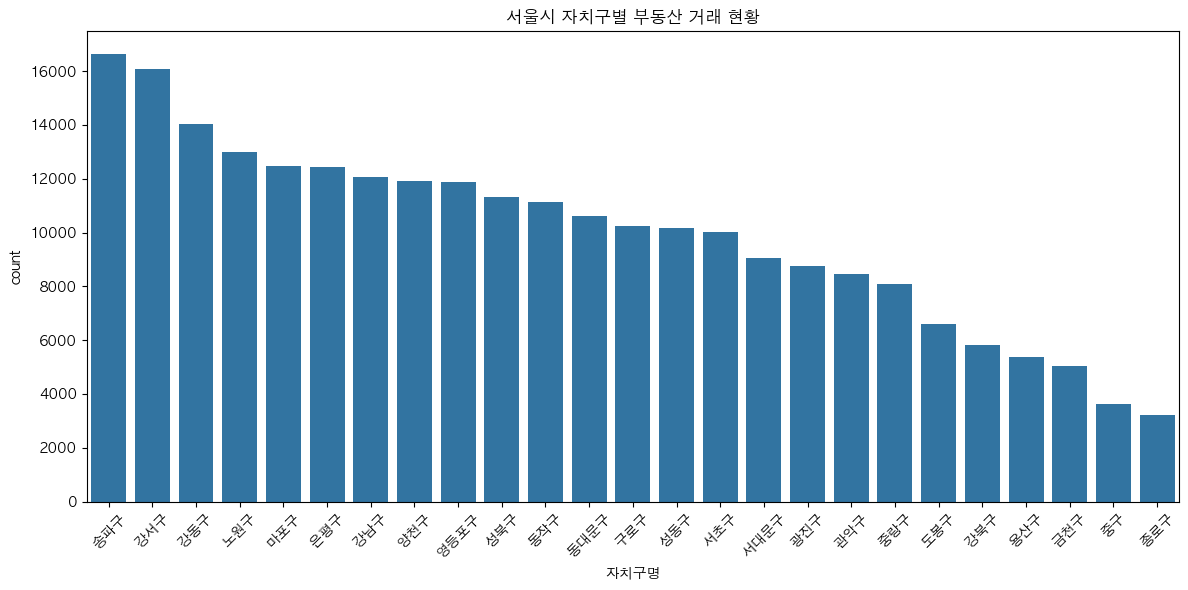


[STEP 1] Linear Regression 학습 시작
Linear Regression 모델 학습 중...

--- [모델 평가 결과] ---
평균 절대 오차 (MAE): 31,062.57 만원
결정계수 (R² Score): 0.6498


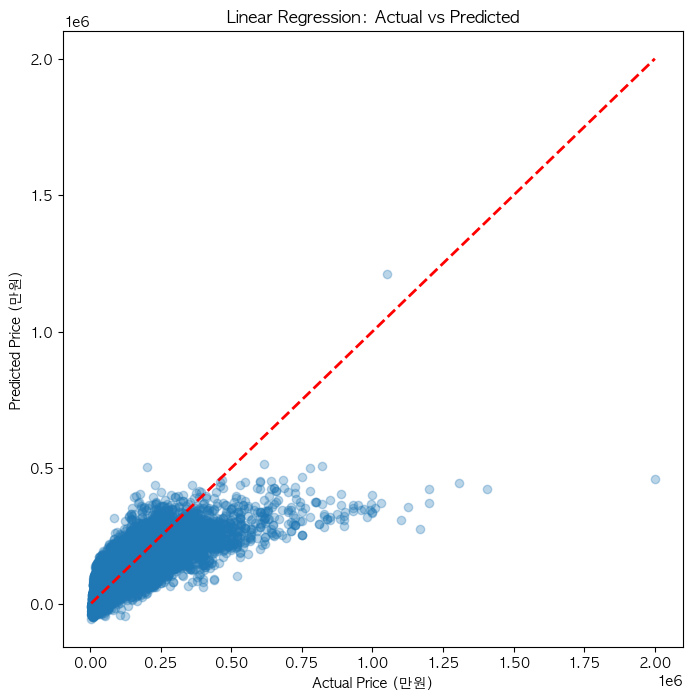


[STEP 2] XGBoost 학습 시작
대표님, 최적의 하이퍼파라미터를 찾는 중입니다 (GridSearchCV)...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
찾아낸 최적 파라미터: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 7, 'regressor__n_estimators': 500}

--- [XGBoost 모델 정밀 분석 결과] ---
평균 절대 오차 (MAE): 13,283.87 만원
결정계수 (R² Score): 0.9162

[STEP 3] 모델 기반 핵심 변수 분석


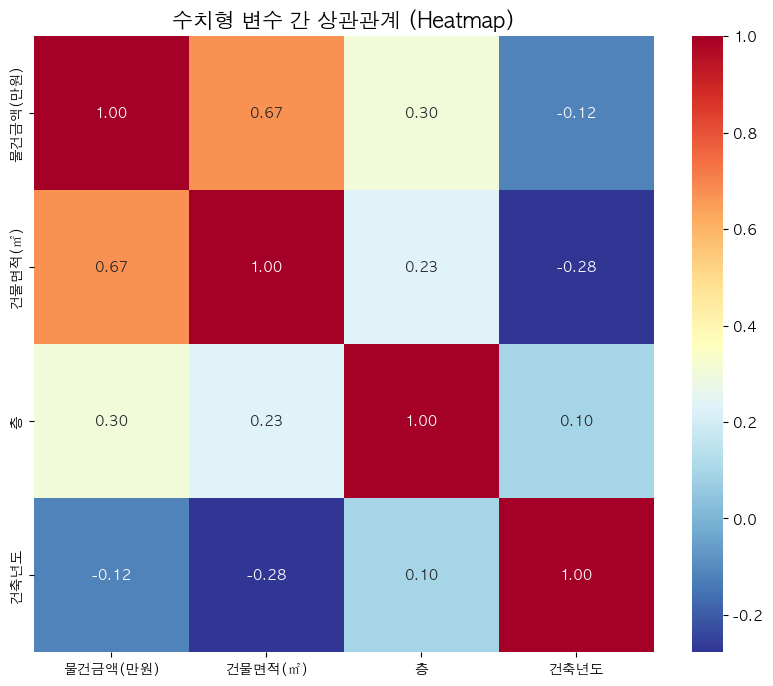

/var/folders/6c/4yg7f8pn51z3n_xr3pxygkt40000gn/T/ipykernel_23454/1884636583.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[all_feature_names[i] for i in indices], palette="rocket")


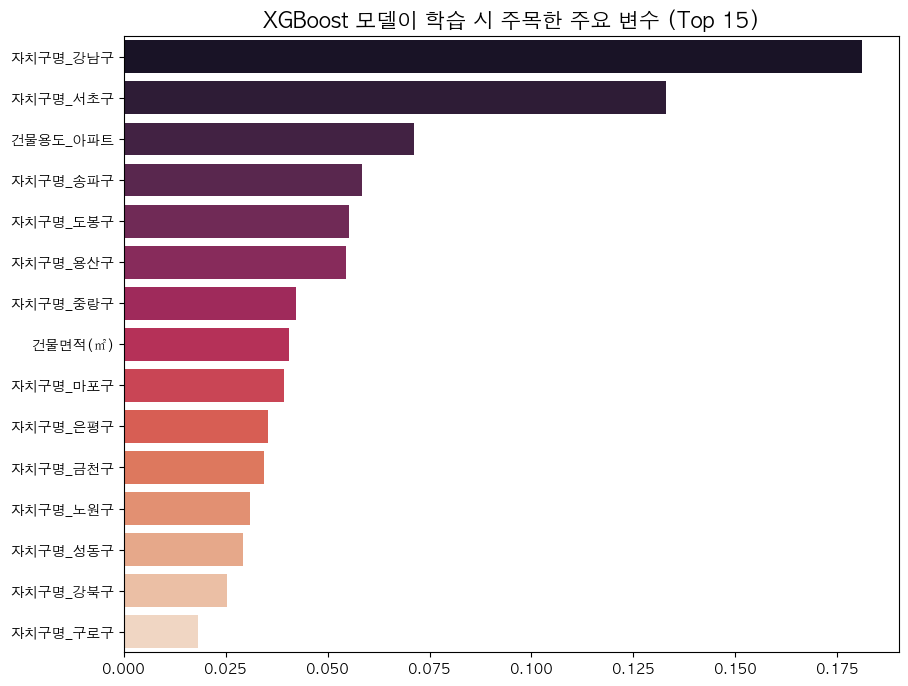


Permutation Importance 계산 중... (데이터 양에 따라 시간이 소요될 수 있습니다)


KeyboardInterrupt: 

In [16]:
DATA_DIR = "datasets"
raw_data = load_data(DATA_DIR)

if not raw_data.empty:
    df_cleaned = preprocess_data(raw_data)
    print(f"정제 후 데이터 수: {len(df_cleaned)}")
    
    perform_eda(df_cleaned)
    
    print("\n[STEP 1] Linear Regression 학습 시작")
    model_lr = train_linear_regression(df_cleaned)
    
    print("\n[STEP 2] XGBoost 학습 시작")
    model_xgb = train_xgboost(df_cleaned)
    
    print("\n[STEP 3] 모델 기반 핵심 변수 분석")
    perm_results = perform_detailed_analysis(model_xgb, df_cleaned)
    
    print("\n모든 작업이 완료되었습니다.")
else:
    print("데이터 로드 실패")

# 모델저장

In [ ]:
# 분석 결과 직렬화 저장
print("\n[저장] 모델 및 정제 데이터 저장 중...")
joblib.dump(model_xgb, 'xgb_model.pkl')
joblib.dump(df_cleaned, 'df_cleaned.pkl')
print("성공적으로 저장되었습니다! 이제 대시보드에서 즉시 확인 가능합니다.")